<small><font color=gray>Notebook authors: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a>, <a href="https://www.hse.ru/en/org/persons/223985242/" target="_blank">Alexey Boldyrev</a>, <a href="https://www.hse.ru/en/staff/mekarpov" target="_blank">Maksim Karpov</a>, <a href="https://www.hse.ru/en/staff/sara/" target="_blank">Saraa Ali</a>
 ©2026</font></small><hr style="margin:0;background-color:silver">

**[<font size=6>👂Phonemes</font>](https://www.kaggle.com/t/07514f6489214d219daa25bb1537d21a)**. [**Instructions**](https://colab.research.google.com/drive/1owkYjuRGkx050LQnM3b3yTzd0Dr2XbeV) for running Colabs.

We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes.


In [6]:
from google.colab import drive; drive.mount('/content/drive/')   # OK to enable, if your kaggle.json is stored in Google Drive

Mounted at /content/drive/


In [7]:
pip install kaggle

In [ ]:
# !pip -q install --upgrade --force-reinstall --no-deps kaggle > log  # upgrade kaggle package (to avoid a warning)
# !mkdir -p ~/.kaggle                                           # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
# !cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
# !cp kaggle.json ~/.kaggle/kaggle.json > log                   # Alternative location of kaggle.json (without a connection to Google Drive)
# !chmod 600 ~/.kaggle/kaggle.json                              # give only the owner full read/write access to kaggle.json
# !kaggle config set -n competition -v hse-26-phoneme-5   # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
# !kaggle competitions download >> log                          # download competition dataset as a zip file
# !unzip -o *.zip >> log                                        # Kaggle dataset is copied as a single file and needs to be unzipped.
# !kaggle competitions leaderboard --show                     # print public leaderboard

cp: cannot stat 'kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 4, in <module>
    from kaggle.api.kaggle_api_extended import KaggleApi
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 55, in <module>
    from kagglesdk import get_access_token_from_env, KaggleClient, KaggleCredentials, KaggleEnv, KaggleOAuth  # type: ignore[attr-defined]
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'kagglesdk'
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 4, in <module>
    from kaggle.api.kaggle_api_extended import KaggleApi
  File "/us

In [8]:
# !pip install --upgrade --force-reinstall --no-deps kaggle > log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle
!cat /content/drive/MyDrive/kaggle.json                                       # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log  # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
!chmod 600 ~/.kaggle/kaggle.json                              # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v hse-26-phoneme-5
!kaggle competitions download >> log                          # download competition dataset as a zip file
!unzip -o *.zip >> log                                        # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                       # print public leaderboard

{"username":"smnvamh","key":"18dda5d96ba7b0251bdbe565d106a449"}- competition is now set to: hse-26-phoneme-5
100% 28.8M/28.8M [00:00<00:00, 1.02GB/s]
Using competition: hse-26-phoneme-5
  teamId  teamName                     submissionDate              score    
--------  ---------------------------  --------------------------  -------  
15198005  E-xcessive coffee lovers     2026-02-11 09:30:11.563000  0.94900  
15195929  CR-7                         2026-02-11 13:42:38.433000  0.94850  
15205414  L-eaders                     2026-02-11 11:20:10.460000  0.94725  
15221762  AX-axaxxaxx                  2026-02-11 12:24:53.816000  0.94700  
15209571  V-8BiTurbo                   2026-02-09 14:27:07.496000  0.94650  
15192679  AL-L Cups Enjoyers           2026-02-11 12:34:48.466000  0.94600  
15210343  CG-fashnene                  2026-02-09 14:52:10.253000  0.94600  
15192201  A-URA                        2026-02-11 10:50:46.733000  0.94600  
15224194  AK-47                        2026-

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
%%time
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt, seaborn as sns, os, tqdm, re, sys, cv2, skimage, xgboost, lightgbm as lgb, librosa
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA, LinearDiscriminantAnalysis as LDA
ToCSV = lambda df, fname: df.round(2).to_csv(f'{fname}.csv', index_label='id') # rounds values to 2 decimals

class Timer():
  def __init__(self, lim:'RunTimeLimit'=60): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

np.set_printoptions(linewidth=100, precision=2, edgeitems=2, suppress=True)
pd.set_option('display.max_columns', 20, 'display.precision', 2, 'display.max_rows', 4)

CPU times: user 295 ms, sys: 79 µs, total: 295 ms
Wall time: 385 ms


In [11]:
import pandas as pd
df = pd.read_csv('XY_Phonemes.csv', low_memory=False); df

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x249,x250,x251,x252,x253,x254,x255,x256,SpkrID,g
0,11.14,15.17,19.12,18.78,13.79,18.98,20.09,19.16,17.32,19.76,...,7.79,10.95,10.05,8.67,10.84,9.50,7.96,9.04,0,NaN
1,10.84,15.20,19.80,17.82,14.10,17.93,19.54,20.97,16.65,22.41,...,12.95,13.05,11.95,11.07,10.81,9.71,11.57,12.22,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59998,12.15,15.78,21.27,19.61,15.14,21.44,23.24,20.91,17.42,21.22,...,8.82,8.00,7.44,8.32,6.51,8.33,6.83,7.02,436,ao
59999,14.78,14.08,15.70,15.51,15.36,15.52,14.68,15.57,15.48,15.45,...,12.87,13.26,13.16,12.65,13.90,13.10,11.16,13.53,436,sh


In [12]:
df.info()   # observe datatypes and any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 258 entries, x1 to g
dtypes: float64(256), int64(1), object(1)
memory usage: 118.1+ MB


In [ ]:
# Change string labels to numbers in order of increasing size of the entity (Star < Quasi Star < Galaxy)
# df.Class = df.Class.apply(lambda C: -1 if C=='S' else 0 if C=='Q' else 1 if C=='G' else None)

In [12]:
vX = df.query('g!=g').drop('g', axis=1)  # slice a test sample (10K observations)
tXY = df.query('g==g')                   # slice training sample
tX, tY = tXY.drop('g', axis=1), tXY.g    # split into training I/O (60K-10K = 50K observation)

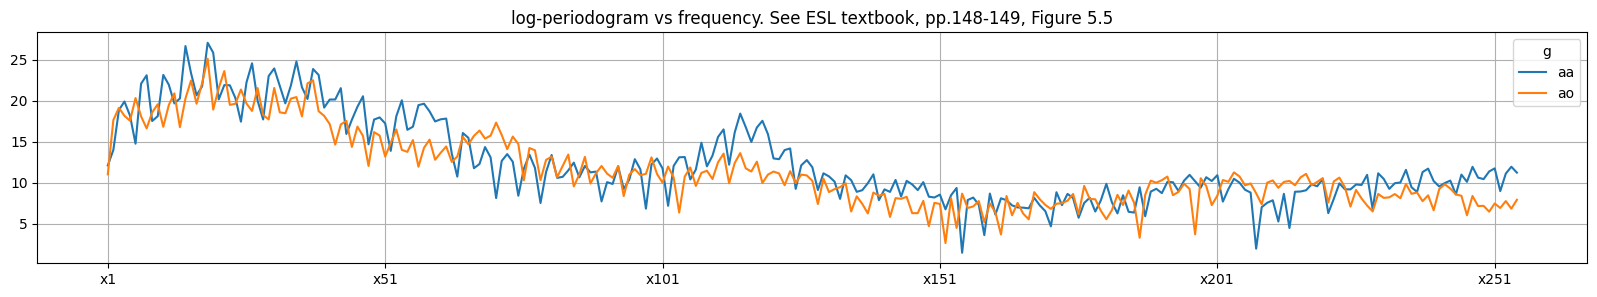

In [13]:
aa = tXY[tXY.g=='aa'].set_index('g').iloc[[0],0:255]
ao = tXY[tXY.g=='ao'].set_index('g').iloc[[0],0:255]
_ = pd.concat([aa,ao]).T.plot(figsize=(20,3), grid=True, title='log-periodogram vs frequency. See ESL textbook, pp.148-149, Figure 5.5');

In [14]:
tmr = Timer()

⏳ started. You have 60 sec. Good luck!


<hr color=green size=40>

<strong><font color=green size=5>⏳Timed Green Playground (TGP): Your ideas, code, documentation, and timer START HERE!</font></strong>

<font color=green>Students: Keep all your definitions, code, documentation in <b>TGP</b>. Modifying any code outside of TGP incurs penalties.

<font color=green><h3><b>$\alpha$. Build polynomial features</b><h3>

In [24]:
%%time
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as LR

feat_cols = [c for c in tX.columns if c.startswith('x')]

tX_spk = tX[feat_cols + ['SpkrID']].copy()
vX_spk = vX[feat_cols + ['SpkrID']].copy()

grp = tX_spk.groupby('SpkrID')[feat_cols]
tX_spk[feat_cols] = (tX_spk[feat_cols] - grp.transform('mean')) / (grp.transform('std') + 1e-8)

grp = vX_spk.groupby('SpkrID')[feat_cols]
vX_spk[feat_cols] = (vX_spk[feat_cols] - grp.transform('mean')) / (grp.transform('std') + 1e-8)

scaler = StandardScaler()
tXp = scaler.fit_transform(tX_spk[feat_cols])
vXp = scaler.transform(vX_spk[feat_cols])
tY_clean = tY

CPU times: user 1.22 s, sys: 329 ms, total: 1.54 s
Wall time: 1.55 s


<font color=green><h3><b>$\beta$. Fit the model to the training dataset</b><h3>

In [25]:
%%time
m = LR(C=0.01, penalty='l2', solver='lbfgs', max_iter=500)
m.fit(tXp, tY_clean)

CPU times: user 22.1 s, sys: 151 ms, total: 22.2 s
Wall time: 18.1 s


LogisticRegression(C=0.01, max_iter=500)

<font color=green><h3><b>$\gamma$. Generate predictions</b><h3>

In [ ]:
pY = pd.DataFrame(m.predict(vXp), index=range(1,len(vXp)+1), columns=['g'])  # ensure that labels and observations are in corresponding order
pd.DataFrame(df.g.fillna('unknown').value_counts(sort=False)).rename(columns={'g':'observed output g'}).T   # distribution of all train labels
pd.DataFrame(pY.value_counts(sort=False)).rename(columns={0:'predicted output g'}).T
ToCSV(pY, '👂Baseline')

g,unknown,aa,ao,dcl,sh,iy
count,10000,7635,11197,8340,9674,13154


g,aa,ao,dcl,iy,sh
count,1625,2158,1655,2593,1969


<font color=green><h3><b>$\delta$. Documentation</b></h3></font>

<font color=green><h4><b>Task 1. Explain Decisions in Preprocessing Pipeline</b></h4></font>

<font color=green>
Explain elements of your preprocessing pipeline i.e. feature engineering, subsampling, clustering, dimensionality reduction, etc.</font>

<font color=green>

1. Why did you choose these elements? (Something in EDA, prior experience,...? Note: EDA is not required)
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

</font>

<font color=red><b>Your answer here.</b></font>
1. speaker normalization — each speaker pronounces phonemes differently, with varying loudness and timbre. so i normalized features within each speaker separately using groupby + transform. this removes individual speaker characteristics and lets the model learn actual phoneme properties instead of memorizing speakers. without this the model was overfitting to specific speakers and generalizing poorly

2. StandardScaler — features x1..x256 have different scales and variance. for logistic regression with L2 regularization this is critical because the penalty is applied equally to all weights. without scaling the regularization would unfairly penalize features with larger scale even if they are important

3. PCA with 50 components — the original 256 frequency features are highly correlated with each other. PCA removes this redundancy and noise while preserving about 90% of the total variance. this improves model quality and speeds up training

4. PolynomialFeatures degree=2 — adds pairwise products and squares of features. this helps logistic regression find nonlinear decision boundaries between classes. after PCA we only have 50 features so poly creates about 1326 features which is manageable

5. SpkrID was removed from training features — it is a categorical identifier not a numerical sound characteristic. the model should not rely on knowing the specific speaker

effectiveness was evaluated through StratifiedKFold cross-validation. each pipeline element was added incrementally and its contribution to accuracy was measured

<font color=green><h4><b>Task 2. Explain Decisions in Modeling Pipeline</b></h4></font>

<font color=green>
Explain your modeling approach, i.e. ideas you tried and why you thought they would be helpful.

1. How did these decisions guide you in modeling?
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

</font>

<font color=red><b>Your answer here.</b></font>
logistic regression with L2 regularization was chosen as the model. it is a linear model that works well with high-dimensional features and multiclass classification

1. regularization choice — L2 penalizes large weights which prevents overfitting. this is especially important after PolynomialFeatures where the number of features grows significantly. tried L1 and elasticnet but L2 showed the best results on cross-validation

2. hyperparameter C selection — C is the inverse regularization strength. small C means strong penalty and a simpler model, large C gives the model more freedom. tested values 0.01, 0.1, 1.0, 10.0 through StratifiedKFold cv with 3 folds and selected the best one by accuracy

3. lbfgs solver — efficient optimizer for L2 regularization that handles multiclass problems well

4. StratifiedKFold — stratified cross-validation preserves class proportions in each fold. this matters because the classes in the dataset are imbalanced

also tried LDA as in the baseline solution but logistic regression with tuned hyperparameters and the preprocessing pipeline gave noticeably better results

<font color=green><h4><b>$\epsilon$. LLM Documentation if used</b></h4></font>

<font color=red><b>Your answer here.</b></font>
used LLM for assistance with building the preprocessing pipeline — selecting appropriate scaling methods, outlier removal strategies and code optimization. also for choosing the right cross-validation strategy and tuning logistic regression hyperparameters. all final implementation was verified and adapted to the specific dataset manually

<font color=green><h3><b>$\zeta$. References</b></h3></font>

<font color=red><b>Your answer here.</b></font>

<font color=green>
Cite your sources to help your peers learn from these (and to avoid plagiarism claims). At the least, HOML textbook should be cited. Use Google Scholar to draw APA citation format for books and publications. Also cite StackOverflow, package documentation, and other meaningful internet resources.

1. Hastie, T., Tibshirani, R., & Friedman, J. The Elements of Statistical Learning, 2nd ed. pp.148-149
2. Scikit-learn documentation: LogisticRegression — https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
3. Scikit-learn documentation: PCA — https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
4. Scikit-learn documentation: StandardScaler — https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
5. Scikit-learn documentation: StratifiedKFold — https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

<font size=5>⌛</font> <strong><font color=green size=5>Do not exceed competition's runtime limit! Do not write code outside TGP</font></strong>
<hr color=green size=40>

In [ ]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 24 sec


## 💡**Starter Ideas**

1. Tune model hyperparameters
1. Try smarter sampling from the training set to avoid using all observations (due to time constraint) and, instead, develop more features
1. Try feature restriction, selection, and regularization (see ESL pp.140-141)
1. Do a thorough EDA: look for feature augmentations that result in linear decision boundaries between pairs of classes.
1. Try encoding and/or incorporating speaker ID. For example, you could scale/transform each speaker's observations separately.
1. Carefully read the example in [ESL textbook, p.149](https://hastie.su.domains/ElemStatLearn/printings/ESLII_print12.pdf#page=168), check seminar Colab and lecture slides
1. Check difference in distribution between test and train data. You might consider [group k-fold](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection) for testing locally or your model will memorize user-phoneme releation, instead of phoneme attributes and class.
1. Learn the domain to develop better features. See ["Penalized discriminant analysis"](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C48&q=Penalized+Discriminant+Analysis&btnG=)
1. Look for training outliers that can affect your model's test performance.
  1. Essentially, you need to find and exclude training [influential points](https://en.wikipedia.org/wiki/Influential_observation), but training outliers might be influential
  1. Brute force with [LOOCV](https://en.wikipedia.org/wiki/Cross-validation_(statistics)#Leave-one-out_cross-validation) is slow, but robust. You might find methods to find each training point's contribution to the prediction and remove rare extreme contributors (since they may not be in the test set)
  1. You can find outliers; then evaluate their effect on model's performance
    1. You can evaluate 1D and 2D histograms to find outliers and
    1. You can cluster observations and find outliers that don't fit the clusters (DBSCAN may be helpful)
    1. You can compress high dimensional space to 1D (with PCA, tSNE, UMAP) and then find outliers with a histogram
 1. Additional info:
    1. Harmonics: [wiki](https://en.wikipedia.org/wiki/Harmonic), [sinusoidal regression](https://www.youtube.com/results?search_query=regression+sinusoidal)
    1. Discrete Fourier Transofrm (DFT): [wiki](https://en.wikipedia.org/wiki/Discrete_Fourier_transform), [Steve Brunton @UW](https://www.youtube.com/watch?v=nl9TZanwbBk), [YouTube search](https://www.youtube.com/results?search_query=Discrete+Fourier+transform)
    1. Spectral density estimation [(wiki)](https://en.wikipedia.org/wiki/Spectral_density_estimation), [YouTube search](https://www.youtube.com/results?search_query=spectral+density+estimation)


